In [1]:
%pip install numpy matplotlib astropy astroquery scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astroquery.sdss import SDSS # dataset que será usado
from scipy.spatial import cKDTree

#ssl._create_default_https_context = ssl._create_unverified_context
#SDSS.TIMEOUT = 300

# coleta dos dados do Sloan Digital Sky Survey
# ra: Ascensão Reta
# dec: Declinação
# z: Redshift
# filtra para garantir que obetenha galáxias que estejam na mesma região

def dados_sdss():
    print("Realizando busca do SDSS...")
    query = """
    SELECT TOP 4000 ra, dec, z
    FROM SpecObj
    WHERE class = 'GALAXY'
      AND z BETWEEN 0.02 AND 0.08
      AND zWarning = 0
      AND ra BETWEEN 150 AND 160
      AND dec BETWEEN 10 AND 20
    """
    table = SDSS.query_sql(query)
    print(f"{len(table)} galaxias foram carregadas\n")
    return table

# construção do grafo (lista de adjacencia)
def construir_grafo(ra, dec, redshifts, b_perp, b_para):
    print("Construindo o Grafo")
    N = len(ra)
    distances = cosmo.comoving_distance(redshifts).value

    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, distance=distances*u.Mpc, frame='icrs')
    cartesian_xyz = coords.cartesian.xyz.value.T

    # cria a arvore tridimencional usando o KDTree para ficar otimizado
    tree = cKDTree(cartesian_xyz)
    max_radius = max(b_perp, b_para)
    potential_pairs = tree.query_ball_tree(tree, r=max_radius)

    # dicionario de listas
    lista_adjacencia = {i: [] for i in range(N)}
    total_arestas = 0

    for current in range(N):
        for neighbor in potential_pairs[current]:
            if current < neighbor:
                # calculo do FOF
                pi_para = abs(distances[current] - distances[neighbor])
                d_mean = (distances[current] + distances[neighbor]) / 2.0
                ang_sep = coords[current].separation(coords[neighbor]).rad
                rp_perp = d_mean * ang_sep

                # adição das arestas (não direcionadas)
                if (rp_perp <= b_perp) and (pi_para <= b_para):
                    dist_3d = np.sqrt(rp_perp**2 + pi_para**2)
                    lista_adjacencia[current].append((neighbor, dist_3d))
                    lista_adjacencia[neighbor].append((current, dist_3d))
                    total_arestas += 1

    print(f"Grafo criado com {N} vértices e {total_arestas} arestas\n")
    return lista_adjacencia

# algorítmo BFS
def bfs_aglomerados(lista_adjacencia):
    print("Buscando por aglomerados (algoritmo BFS)")
    N = len(lista_adjacencia)
    visited = [False] * N
    grupos = []

    for i in range(N):
        if not visited[i]:
            queue = [i]
            visited[i] = True
            grupo = []

            while queue:
                u = queue.pop(0)
                grupo.append(u)

                for v, peso in lista_adjacencia[u]:
                    if not visited[v]:
                        visited[v] = True
                        queue.append(v)

            grupos.append(grupo)

    return grupos

# pipeline de execução

# baixando os dados
sdss_table = dados_sdss()
ra_arr = np.array(sdss_table['ra'])
dec_arr = np.array(sdss_table['dec'])
z_arr = np.array(sdss_table['z'])

# cálculo do linking length
n_galaxias = len(ra_arr)

d_min = cosmo.comoving_distance(0.02).value # Mpc
d_max = cosmo.comoving_distance(0.08).value # Mpc

delta_ra = np.radians(10)
delta_dec = np.sin(np.radians(20)) - np.sin(np.radians(10))
area_angular = delta_ra * delta_dec

volume_observado = (1/3) * area_angular * (d_max**3 - d_min**3)
separacao_media = (volume_observado / n_galaxias) ** (1 / 3)

# fator duplo do linking length
b_perp_fator = 0.15 # distância de ligação transversal, distância da separação media entre duas galáxias com mesmo redshift
b_para_fator = 1.5 # distância de ligação na linha de visada, para corrigir o efeito FOG

link_perp = b_perp_fator * separacao_media
link_para = b_para_fator * separacao_media

print(f"Volume aproximado do patch SDSS: {volume_observado:.2f} Mpc³")
print(f"Separação média entre galáxias (lambda): {separacao_media:.2f} Mpc")
print(f"Linking Length calculado => Transversal (link_perp): {link_perp:.2f} Mpc / Linha de Visada (link_para): {link_para:.2f} Mpc\n")

# modelagem e representação do grafo
grafo_galaxia = construir_grafo(ra_arr, dec_arr, z_arr, link_perp, link_para)

# algoritmo de Busca (FOF baseado em BFS)
total_grupos = bfs_aglomerados(grafo_galaxia)

# filtrando grupos com pelo menos 2 galáxias
aglomerados_validos = [g for g in total_grupos if len(g) > 1]
aglomerados_validos.sort(key=len, reverse=True)

# filtrando galáxias que não estão em nenhum grupo
galaxias_isoladas = [g for g in total_grupos if len(g) == 1]

Realizando busca do SDSS...
3181 galaxias foram carregadas

Volume aproximado do patch SDSS: 405234.41 Mpc³
Separação média entre galáxias (lambda): 5.03 Mpc
Linking Length calculado => Transversal (link_perp): 0.75 Mpc / Linha de Visada (link_para): 7.55 Mpc

Construindo o Grafo
Grafo criado com 3181 vértices e 4544 arestas

Buscando por aglomerados (algoritmo BFS)


In [3]:

# Análise 1: Conectividade dos Aglomerados

print(f"\nAnálise de Conectividade")
print(f"Foram encontrados {len(aglomerados_validos)} aglomerados de galáxias/subgrafos válidos (com 2 ou mais galáxias).")
print(f"Quantidade de galáxias isoladas/sem um aglomerado (field galaxies): {len(galaxias_isoladas)}")
if len(aglomerados_validos) > 0:
    print(f"O maior aglomerado encontrado possui {len(aglomerados_validos[0])} galáxias.")
else:
    print("Nenhum aglomerado com mais de 2 galáxias foi encontrado.")



Análise de Conectividade
Foram encontrados 472 aglomerados de galáxias/subgrafos válidos (com 2 ou mais galáxias).
Quantidade de galáxias isoladas/sem um aglomerado (field galaxies): 1022
O maior aglomerado encontrado possui 71 galáxias.


In [4]:
# Análise 2: cálculo de grau e identificação de vértices importantes

# encontra o nó com mais arestas
graus = {v: len(vizinhos) for v, vizinhos in grafo_galaxia.items()}
galaxia_mais_densa = max(graus, key=graus.get)
maior_grau = graus[galaxia_mais_densa]

print(f"\nCálculo de Grau e Identificação de Vértices Importantes")
print(f"O nó que possui a maior conectividade direta é a galáxia de ID {galaxia_mais_densa}.")
print(f"Ela possui Grau = {maior_grau} (está conectada diretamente a {maior_grau} outras galáxias).")


Cálculo de Grau e Identificação de Vértices Importantes
O nó que possui a maior conectividade direta é a galáxia de ID 464.
Ela possui Grau = 28 (está conectada diretamente a 28 outras galáxias).


In [5]:
# Análise 3: nó central e extremidade do aglomerado (BFS)

print(f"\nAnálise de caminho do maior aglomerado, identificação do centro (vértice importante) e caminho do vértice mais distante do centro do aglomerado")
if len(aglomerados_validos) > 0:
    maior_aglomerado = aglomerados_validos[0]

    # identificar o centro interno do maior aglomerado
    graus_internos = {v: len([viz for viz, peso in grafo_galaxia[v] if viz in maior_aglomerado]) for v in maior_aglomerado}
    centro_id = max(graus_internos, key=graus_internos.get)

    # BFS partindo do nó central desse subgrafo para encontrar o nó mais distante
    aglomerados_visitados = {centro_id}
    fila = [(centro_id, 0)]

    no_mais_distante = centro_id
    distancia_maxima = 0

    while fila:
        atual, dist = fila.pop(0)

        if dist > distancia_maxima:
            distancia_maxima = dist
            no_mais_distante = atual

        for vizinho, peso in grafo_galaxia[atual]:
            if vizinho not in aglomerados_visitados:
                aglomerados_visitados.add(vizinho)
                fila.append((vizinho, dist + 1))

    print(f"O nucleo/centro do maior aglomerado de galáxias é a galáxia de ID {centro_id} (com {graus_internos[centro_id]} conexões internas).")
    print(f"A galáxia desse aglomerado mais distante desse centro é a de ID {no_mais_distante}.")
    print(f"A distância máxima do aglomerado é de {distancia_maxima} arestas.")
else:
    print("Nenhum aglomerado com mais de 2 galáxias encontrado.")


Análise de caminho do maior aglomerado, identificação do centro (vértice importante) e caminho do vértice mais distante do centro do aglomerado
O nucleo/centro do maior aglomerado de galáxias é a galáxia de ID 1224 (com 18 conexões internas).
A galáxia desse aglomerado mais distante desse centro é a de ID 1237.
A distância máxima do aglomerado é de 7 arestas.


In [6]:
# printa a lista completa de todos os aglomerados encontrados

print("\nLista de todos os aglomerados com a quantidade de galáxias que possui.")
for i, grupo in enumerate(aglomerados_validos[:len(aglomerados_validos)]):
    print(f"Aglomerado {i + 1}: contém {len(grupo)} galáxias. Redshift médio: {np.mean(z_arr[grupo]):.4f}")


Lista de todos os aglomerados com a quantidade de galáxias que possui.
Aglomerado 1: contém 71 galáxias. Redshift médio: 0.0443
Aglomerado 2: contém 67 galáxias. Redshift médio: 0.0319
Aglomerado 3: contém 63 galáxias. Redshift médio: 0.0298
Aglomerado 4: contém 63 galáxias. Redshift médio: 0.0448
Aglomerado 5: contém 45 galáxias. Redshift médio: 0.0322
Aglomerado 6: contém 33 galáxias. Redshift médio: 0.0639
Aglomerado 7: contém 27 galáxias. Redshift médio: 0.0784
Aglomerado 8: contém 25 galáxias. Redshift médio: 0.0330
Aglomerado 9: contém 24 galáxias. Redshift médio: 0.0424
Aglomerado 10: contém 23 galáxias. Redshift médio: 0.0330
Aglomerado 11: contém 22 galáxias. Redshift médio: 0.0328
Aglomerado 12: contém 20 galáxias. Redshift médio: 0.0612
Aglomerado 13: contém 19 galáxias. Redshift médio: 0.0471
Aglomerado 14: contém 18 galáxias. Redshift médio: 0.0322
Aglomerado 15: contém 18 galáxias. Redshift médio: 0.0339
Aglomerado 16: contém 18 galáxias. Redshift médio: 0.0772
Aglomerad

#  Vizualisações - Graficos do projeto

## Grafico 1: distribuição das galáxias no céu, e mapa de cores de acordo com a distância

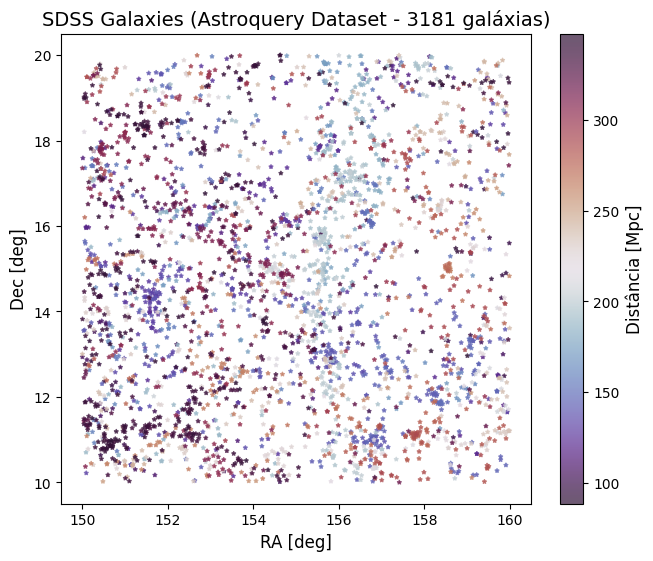

In [7]:
plt.style.use('default')
distances = cosmo.comoving_distance(z_arr).value # Mpc

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
cs = ax.scatter(
    ra_arr,
    dec_arr,
    c=distances,
    s=8,
    marker="*",
    vmin=distances.min(),
    vmax=distances.max(),
    cmap="twilight_shifted",
    alpha=0.7
)

cb = fig.colorbar(cs)
cb.set_label("Distância [Mpc]", fontsize=12)

ax.set_xlabel("RA [deg]", fontsize=12)
ax.set_ylabel("Dec [deg]", fontsize=12)
ax.set_title(f"SDSS Galaxies (Astroquery Dataset - {len(ra_arr)} galáxias)", fontsize=14)

ax.set_aspect('equal', adjustable='box')

plt.show()

## Grafico 2: visualização dos maiores aglomerados encontrados

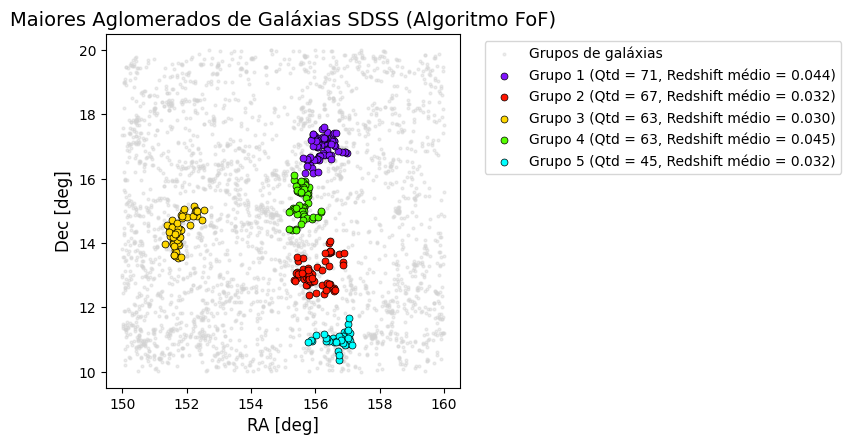

In [8]:
distances = cosmo.comoving_distance(z_arr).value  # Mpc

fig, ax = plt.subplots(figsize=(8, 6.5), constrained_layout=True)

ax.scatter(
    ra_arr,
    dec_arr,
    c='lightgrey',
    s=4,
    alpha=0.4,
    label='Grupos de galáxias'
)

grupo_colors = ["#8214FF", "#FF1500", '#FFD700', "#55FF00", '#00FFFF']

top_grupos = min(5, len(aglomerados_validos))

for i in range(top_grupos):
    indices_grupo = aglomerados_validos[i]
    color = grupo_colors[i % len(grupo_colors)]

    g_ra = ra_arr[indices_grupo]
    g_dec = dec_arr[indices_grupo]
    g_dist = distances[indices_grupo]

    sc = ax.scatter(
        g_ra,
        g_dec,
        c=color,
        s=25,
        edgecolors='black',
        linewidths=0.5,
        label=f'Grupo {i+1} (Qtd = {len(indices_grupo)}, Redshift médio = {np.mean(z_arr[indices_grupo]):.3f})'
    )

ax.set_xlabel("RA [deg]", fontsize=12)
ax.set_ylabel("Dec [deg]", fontsize=12)
ax.set_title(f"Maiores Aglomerados de Galáxias SDSS (Algoritmo FoF)", fontsize=14)

ax.set_aspect('equal', adjustable='box')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=True)

plt.show()

## Grafico 3: mapa de densidade dos aglomerados usando o Gaussian2D

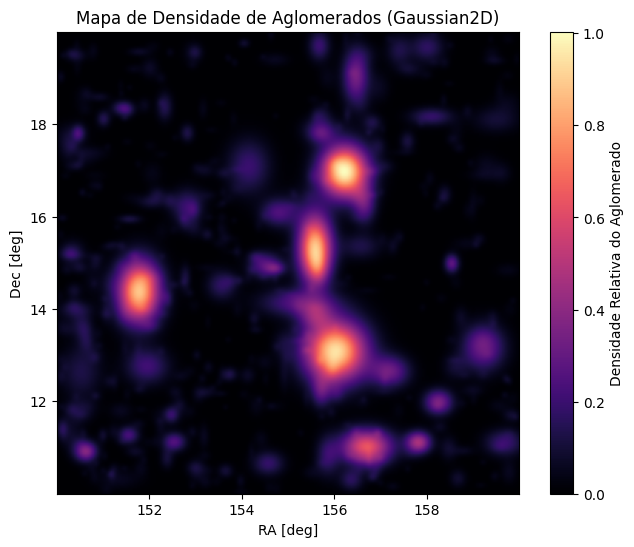

In [9]:
from astropy.modeling.models import Gaussian2D

ra_min, ra_max = ra_arr.min(), ra_arr.max()
dec_min, dec_max = dec_arr.min(), dec_arr.max()

y_grid, x_grid = np.mgrid[dec_min:dec_max:300j, ra_min:ra_max:300j]
data = np.zeros(x_grid.shape)

for indices_grupo in aglomerados_validos:
    g_ra = ra_arr[indices_grupo]
    g_dec = dec_arr[indices_grupo]

    amplitude = len(indices_grupo) / len(aglomerados_validos[0])
    x_mean = np.mean(g_ra)
    y_mean = np.mean(g_dec)
    x_stddev = np.std(g_ra) + 0.05
    y_stddev = np.std(g_dec) + 0.05

    g = Gaussian2D(amplitude, x_mean, y_mean, x_stddev, y_stddev)
    data += g(x_grid, y_grid)


fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, extent=[ra_min, ra_max, dec_min, dec_max],
               origin='lower', cmap='magma', aspect='equal')

plt.colorbar(im, label='Densidade Relativa do Aglomerado')
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Mapa de Densidade de Aglomerados (Gaussian2D)')
plt.show()


## Grafico 4: visualização da região dos aglomerados usando o Aitoff e projeção 3D

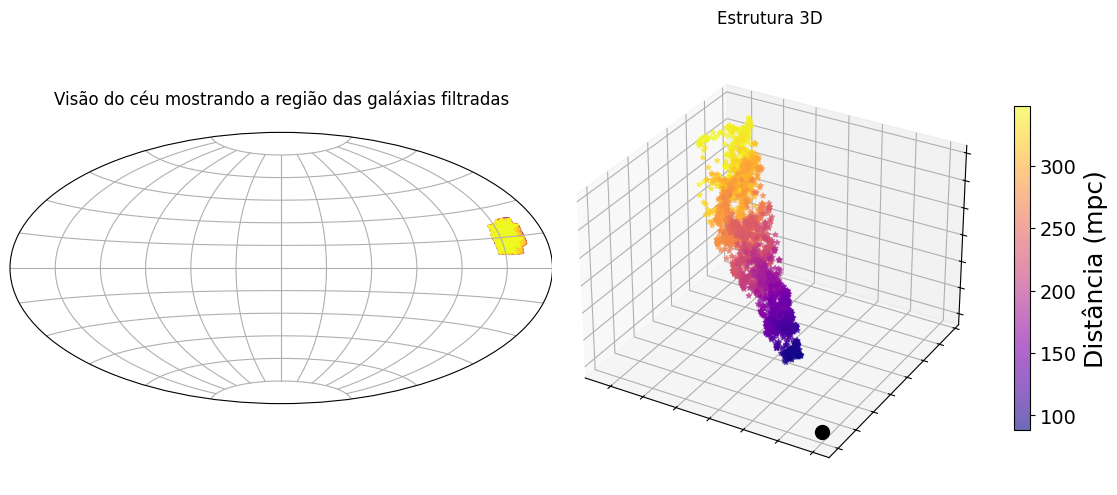

In [10]:
def star_plot(star_coords, vmin=None, vmax=None):
    if not vmin:
        vmin = star_coords.distance.min().value

    if not vmax:
        vmax = star_coords.distance.max().value

    fig = plt.figure(figsize=(14, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection="aitoff")

    ax1.set_xticklabels([])
    ax1.set_yticklabels([])
    ax1.grid(True)

    ax1.set_title("Visão do céu mostrando a região das galáxias filtradas", pad=20)

    ax1.scatter(
        star_coords.ra.wrap_at(180 * u.deg).radian,
        star_coords.dec.radian,
        c=star_coords.distance,
        vmin=vmin,
        vmax=vmax,
        marker="*",
        s=150,
        alpha=0.7,
        cmap="plasma",
    )

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_zticklabels([])

    ax2.set_title("Estrutura 3D", pad=20)

    ax2.scatter([0], [0], [0], s=100, c="k", marker="o")

    pc = ax2.scatter(
        star_coords.cartesian.x,
        star_coords.cartesian.y,
        star_coords.cartesian.z,
        c=star_coords.distance,
        s=15,
        alpha=0.6,
        vmin=vmin,
        vmax=vmax,
        marker="*",
        cmap="plasma",
    )

    cbar = fig.colorbar(pc, shrink=0.6, location="right")
    cbar.ax.tick_params(labelsize=14)
    cbar.ax.set_ylabel("Distância (mpc)", fontsize=18)

    fig.subplots_adjust(wspace=0)

    plt.close()

    return fig

distances_mpc = cosmo.comoving_distance(z_arr)
coords_for_plot = SkyCoord(ra=ra_arr*u.deg, dec=dec_arr*u.deg, distance=distances_mpc, frame='icrs')

star_plot(coords_for_plot)